<a href="https://colab.research.google.com/github/Shashank18ram/Data-Science/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
market=pd.read_csv('/content/market.csv')
market.head()

,Region,Product,Subsidiary,Stores,Sales,Inventory,Returns
0,Africa,Boot,Addis Ababa,12,29761,191821,769
1,Africa,Men's Casual,Addis Ababa,4,67242,118036,2284
2,Africa,Men's Dress,Addis Ababa,7,76793,136273,2433
3,Africa,Sandal,Addis Ababa,10,62819,204284,1861
4,Africa,Slipper,Addis Ababa,14,68641,279795,1771


In [ ]:
market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Region      390 non-null    object
 1   Product     390 non-null    object
 2   Subsidiary  390 non-null    object
 3   Stores      390 non-null    int64 
 4   Sales       390 non-null    int64 
 5   Inventory   390 non-null    int64 
 6   Returns     390 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 21.5+ KB


In [ ]:
market.describe()

,Stores,Sales,Inventory,Returns
count,390.000000,390.000000,3.900000e+02,390.000000
mean,11.502564,76313.023077,2.261371e+05,2659.658974
std,8.804868,95418.194363,2.679502e+05,3323.966711
min,1.000000,325.000000,3.740000e+02,10.000000
25%,3.000000,15124.500000,4.264050e+04,575.000000
50%,10.000000,38005.500000,1.181490e+05,1407.000000
75%,17.000000,104344.750000,3.280922e+05,3438.500000
max,41.000000,502636.000000,1.555357e+06,20470.000000


In [ ]:
market.isnull().sum()

,0
Region,0
Product,0
Subsidiary,0
Stores,0
Sales,0
Inventory,0
Returns,0


In [ ]:
market.duplicated().sum()

np.int64(0)

In [ ]:
#market['Sales']=pd.to_datetime(market['Sales'])

In [ ]:
market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Region      390 non-null    object
 1   Product     390 non-null    object
 2   Subsidiary  390 non-null    object
 3   Stores      390 non-null    int64 
 4   Sales       390 non-null    int64 
 5   Inventory   390 non-null    int64 
 6   Returns     390 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 21.5+ KB


In [ ]:
#converting the int to float64
market['Stores']=market['Stores'].astype(np.float64)

In [ ]:
#market['Month']=market['Sales'].dt.month

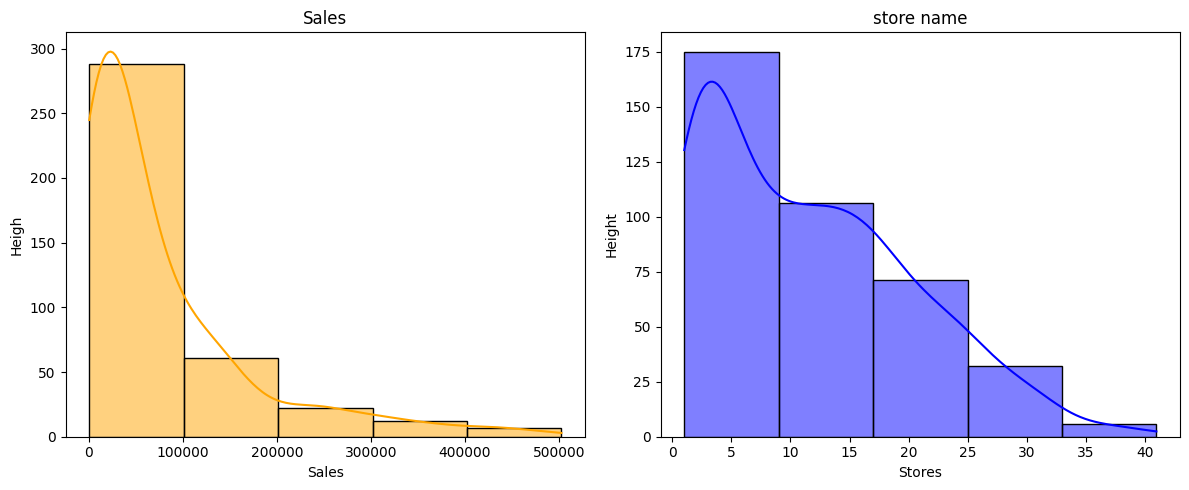

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.histplot(market['Sales'],bins=5,kde=True,color='orange',ax=axes[0])
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Heigh')
axes[0].set_title('Sales')
sns.histplot(market['Stores'],bins=5,kde=True,color='blue',ax=axes[1])
axes[1].set_xlabel('Stores')
axes[1].set_ylabel('Height')
axes[1].set_title('store name')
plt.tight_layout()
plt.show()

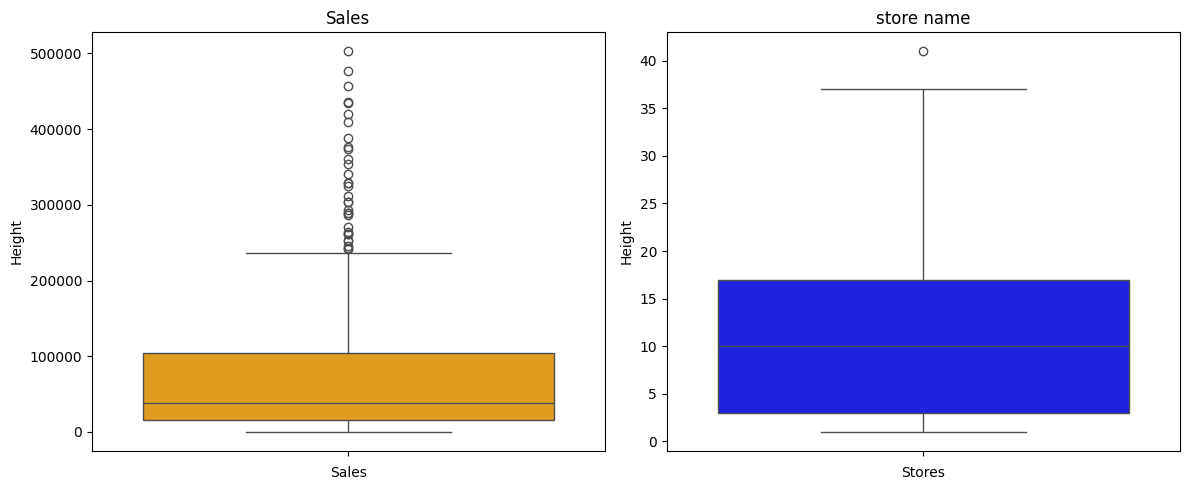

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.boxplot(market['Sales'],color='orange',ax=axes[0])
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Height')
axes[0].set_title('Sales')
sns.boxplot(market['Stores'],color='blue',ax=axes[1])
axes[1].set_xlabel('Stores')
axes[1].set_ylabel('Height')
axes[1].set_title('store name')
plt.tight_layout()
plt.show()

In [ ]:
#dfmovie['genres'].fillna('sunny',inplace=True)

In [ ]:
market.loc[0, 'Sales'] = 500000

In [ ]:
#Outliers
q1=market['Sales'].quantile(0.25)
q3=market['Sales'].quantile(0.75)
iqr=q3-q1
print(q1)
print(q3)
print(iqr)


15124.5
106097.75
90973.25


In [ ]:
q1-1.5*iqr

np.float64(-121335.375)

In [ ]:
q1=market['Inventory'].quantile(0.25)
q3=market['Inventory'].quantile(0.75)
iqr=q3-q1
print(q1)
print(q3)
print(iqr)

42640.5
328092.25
285451.75


In [ ]:
q3+1.5*iqr

np.float64(756269.875)

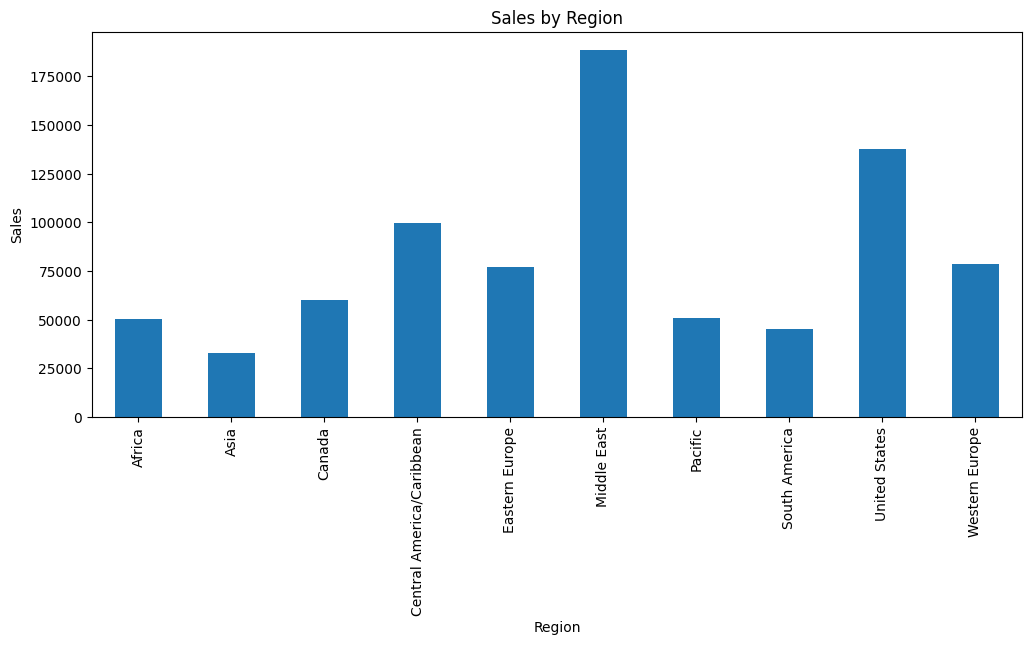

In [ ]:
figure=plt.figure(figsize=(12,5))
market.groupby('Region')['Sales'].mean().plot(kind='bar')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.title('Sales by Region')
plt.show()

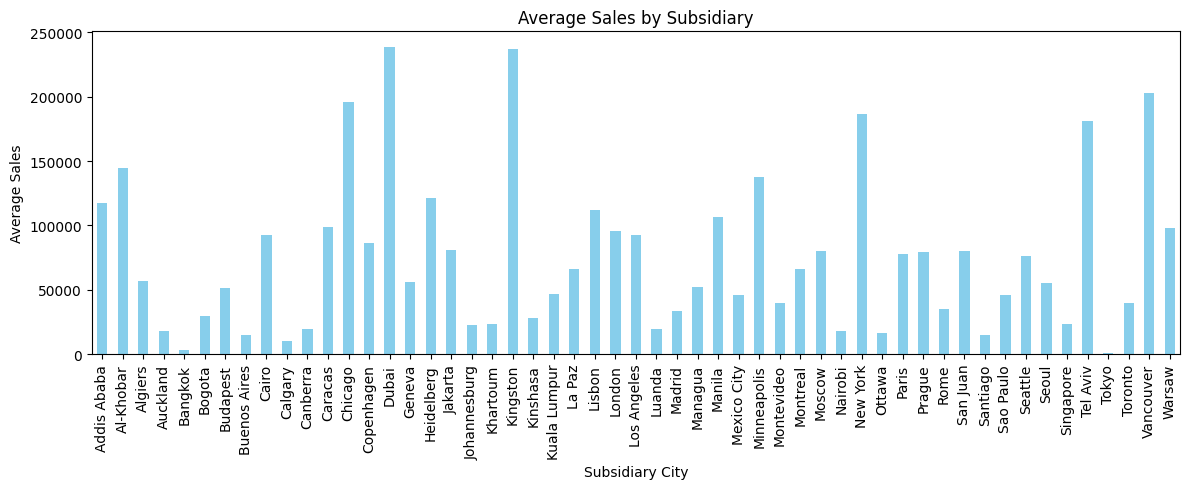

In [ ]:
figure = plt.figure(figsize=(12, 5))
# Grouping by city/subsidiary will give you many more bars!
market.groupby('Subsidiary')['Sales'].mean().plot(kind='bar', color='skyblue')

plt.xlabel('Subsidiary City')
plt.ylabel('Average Sales')
plt.title('Average Sales by Subsidiary')
plt.xticks(rotation=90) # Tilts the text so city names don't overlap
plt.tight_layout()
plt.show()

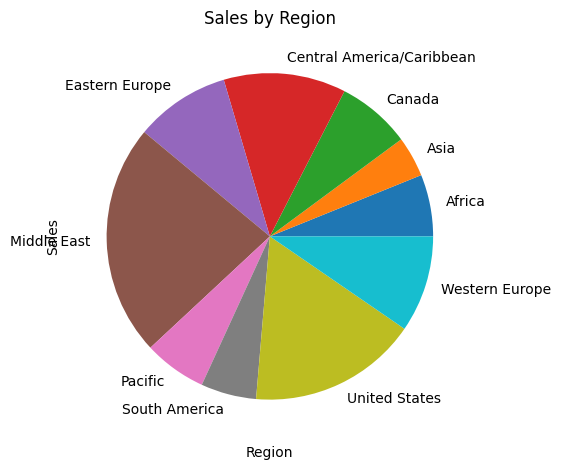

In [ ]:
market.groupby('Region')['Sales'].mean().plot(kind='pie',color='green')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.title('Sales by Region')
plt.xticks(rotation=90) # Tilts the text so city names don't overlap
plt.tight_layout()
plt.show()


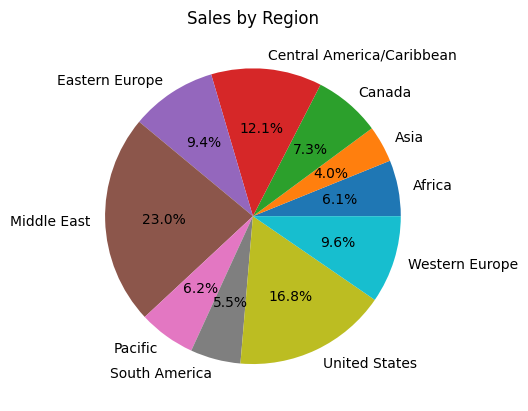

In [ ]:
Region_Sales=market.groupby('Region')['Sales'].mean()
plt.pie(Region_Sales,labels=Region_Sales.index,autopct='%1.1f%%')
plt.title('Sales by Region')
plt.show()
#autoplot used to show the value inside
#index used for showing the regions or country

In [ ]:
market['Inventory'].skew()

np.float64(1.9258874289437535)

In [ ]:
market['Inventory'].kurt()

np.float64(3.948535435693472)